In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
df_clean = pd.read_excel("cleaned_data.xlsx");

In [3]:
refrence_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1);
refrence_date

Timestamp('2011-12-10 12:50:00')

In [4]:
rfm_df = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (refrence_date - x.max()).days,
    'InvoiceNo':'nunique',
    'TransactionValue': 'sum'
}).reset_index();

In [5]:
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TransactionValue': 'Monetary'
},inplace=True);

In [6]:
print("\n --RFM features--");
rfm_df


 --RFM features--


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4333,18280,278,1,180.60
4334,18281,181,1,80.82
4335,18282,8,2,178.05
4336,18283,4,16,2045.53


In [7]:
#applying rfm scores from 1-4 using pandas qcut operations
rfm_df['R_score']=pd.qcut(rfm_df['Recency'],q=4,labels=[4,3,2,1]);
rfm_df['F_score']=pd.qcut(rfm_df['Frequency'].rank(method='first'),q=4,labels=[1,2,3,4]);
rfm_df['M_score']=pd.qcut(rfm_df['Monetary'],q=4,labels=[1,2,3,4]);


In [8]:
rfm_df['RFM_segment']=rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str);
rfm_df['RFM_score']=rfm_df[['R_score', 'F_score', 'M_score']].sum(axis=1);

In [ ]:
print("\n --RFM table--");
print(rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_segment', 'RFM_score']].head(10));



 --RFM table--
   CustomerID  Recency  Frequency  Monetary RFM_segment  RFM_score
0       12346      326          1  77183.60         114          6
1       12347        2          7   4310.00         444         12
2       12348       75          4   1797.24         234          9
3       12349       19          1   1757.55         314          8
4       12350      310          1    334.40         112          4
5       12352       36          8   2506.04         344         11
6       12353      204          1     89.00         111          3
7       12354      232          1   1079.40         113          5
8       12355      214          1    459.40         112          4
9       12356       23          3   2811.43         334         10


C:\Users\User\AppData\Local\Temp\ipykernel_2860\995350414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RFM_score',data=rfm_df,palette='rainbow');


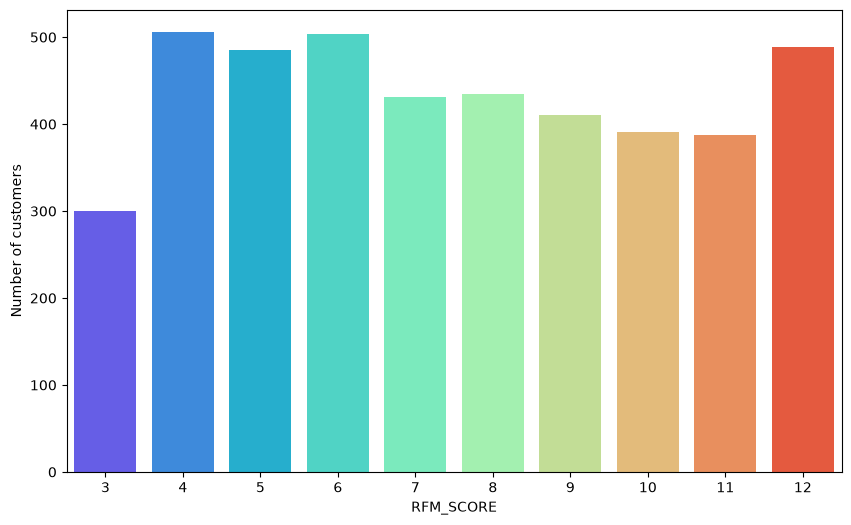

In [10]:
#visuaizing of customer groups based on rfm scores
plt.figure(figsize=(10,6));
sns.countplot(x='RFM_score',data=rfm_df,palette='rainbow');
plt.xlabel("RFM_SCORE");
plt.ylabel("Number of customers");
plt.show();

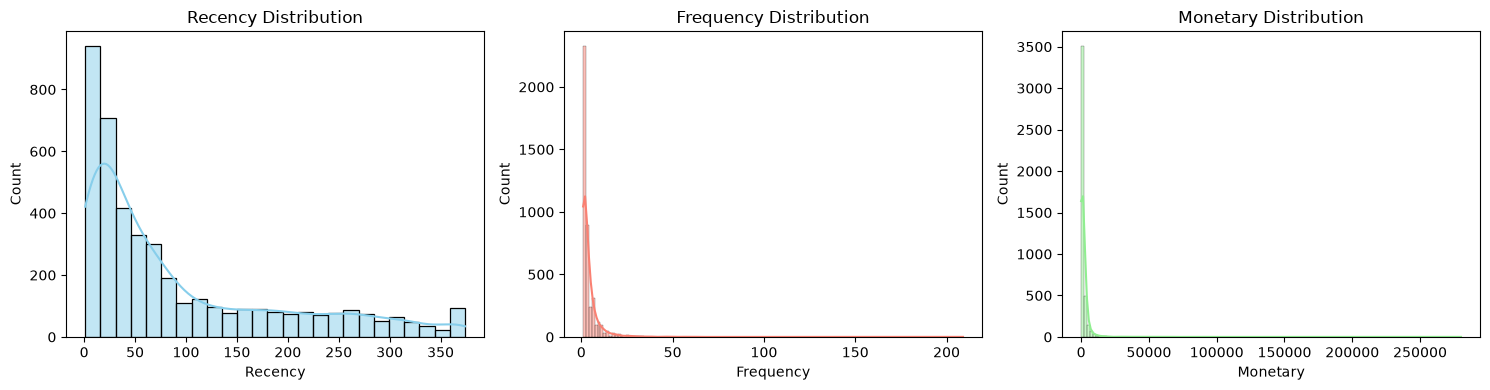

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm_df['Recency'], kde=True, ax=axes[0], color='skyblue').set_title('Recency Distribution')
sns.histplot(rfm_df['Frequency'], kde=True, ax=axes[1], color='salmon').set_title('Frequency Distribution')
sns.histplot(rfm_df['Monetary'], kde=True, ax=axes[2], color='lightgreen').set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [12]:
#feature engineering acc to docxs
customer_features = df_clean.groupby('CustomerID').agg(
    Total_Revenue=('TransactionValue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Items=('Quantity', 'sum'),
    Unique_Products=('StockCode', 'nunique'),           # Unique products purchased
    Most_Recent_Purchase=('InvoiceDate', 'max'),        # Most recent purchase date
    First_Purchase=('InvoiceDate', 'min')
).reset_index();

In [13]:
customer_features['Avg_Order_Value'] = customer_features['Total_Revenue'] / customer_features['Total_Orders']

In [14]:
customer_features['Avg_Items_Per_Order'] = customer_features['Total_Items'] / customer_features['Total_Orders']

In [15]:
customer_features['Tenure_Months']=(customer_features['Most_Recent_Purchase']-customer_features['First_Purchase']).dt.days/30
#using clip so that if persons first or last purchase is within same month then it shows feq as 1
customer_features['Tenure_Months'] = customer_features['Tenure_Months'].clip(lower=1.0)
customer_features['Purchases_Per_Month'] = customer_features['Total_Orders'] / customer_features['Tenure_Months']


In [16]:
preffered_country = df_clean.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0]).reset_index();
preffered_country.rename(columns={'Country':'Preffered_Country'},inplace=True);
customer_features = pd.merge(customer_features,preffered_country,on='CustomerID',how='left')

In [17]:
customer_features

,CustomerID,Total_Revenue,Total_Orders,Total_Items,Unique_Products,Most_Recent_Purchase,First_Purchase,Avg_Order_Value,Avg_Items_Per_Order,Tenure_Months,Purchases_Per_Month,Preffered_Country
0,12346,77183.60,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,74215.000000,1.000000,1.000000,United Kingdom
1,12347,4310.00,7,2458,103,2011-12-07 15:52:00,2010-12-07 14:57:00,615.714286,351.142857,12.166667,0.575342,Iceland
2,12348,1797.24,4,2341,22,2011-09-25 13:13:00,2010-12-16 19:09:00,449.310000,585.250000,9.400000,0.425532,Finland
3,12349,1757.55,1,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,631.000000,1.000000,1.000000,Italy
4,12350,334.40,1,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,197.000000,1.000000,1.000000,Norway
...,...,...,...,...,...,...,...,...,...,...,...,...
4333,18280,180.60,1,45,10,2011-03-07 09:52:00,2011-03-07 09:52:00,180.600000,45.000000,1.000000,1.000000,United Kingdom
4334,18281,80.82,1,54,7,2011-06-12 10:53:00,2011-06-12 10:53:00,80.820000,54.000000,1.000000,1.000000,United Kingdom
4335,18282,178.05,2,103,12,2011-12-02 11:43:00,2011-08-05 13:35:00,89.025000,51.500000,3.933333,0.508475,United Kingdom
4336,18283,2045.53,16,1357,263,2011-12-06 12:02:00,2011-01-06 14:14:00,127.845625,84.812500,11.100000,1.441441,United Kingdom


In [18]:
#product diversity is unique prodcts/quantity
customer_features['Product_Diversity_Ratio'] = customer_features['Unique_Products'] / customer_features['Total_Items']

In [19]:
cancellations_df = pd.read_excel('Cancellations.xlsx');

In [20]:
cancel_counts = cancellations_df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index();
cancel_counts.rename(columns={'InvoiceNo':'Total_Cancellations'},inplace=True);



In [21]:
customer_features = pd.merge(customer_features,cancel_counts,on='CustomerID',how='left')
customer_features['Total_Cancellations']=customer_features['Total_Cancellations'].fillna(0);
#cancellation rate = total cancellation / (successfull orders + cancellations)
customer_features['Cancellation_rate']=customer_features['Total_Cancellations']/(customer_features['Total_Orders']+customer_features['Total_Cancellations']);


In [22]:
#dropping temporary tables
customer_features.drop(columns=['Total_Revenue','Total_Items','First_Purchase','Tenure_Months','Total_Cancellations'],inplace=True)

In [23]:
customer_features

,CustomerID,Total_Orders,Unique_Products,Most_Recent_Purchase,Avg_Order_Value,Avg_Items_Per_Order,Purchases_Per_Month,Preffered_Country,Product_Diversity_Ratio,Cancellation_rate
0,12346,1,1,2011-01-18 10:01:00,77183.600000,74215.000000,1.000000,United Kingdom,0.000013,0.500000
1,12347,7,103,2011-12-07 15:52:00,615.714286,351.142857,0.575342,Iceland,0.041904,0.000000
2,12348,4,22,2011-09-25 13:13:00,449.310000,585.250000,0.425532,Finland,0.009398,0.000000
3,12349,1,73,2011-11-21 09:51:00,1757.550000,631.000000,1.000000,Italy,0.115689,0.000000
4,12350,1,17,2011-02-02 16:01:00,334.400000,197.000000,1.000000,Norway,0.086294,0.000000
...,...,...,...,...,...,...,...,...,...,...
4333,18280,1,10,2011-03-07 09:52:00,180.600000,45.000000,1.000000,United Kingdom,0.222222,0.000000
4334,18281,1,7,2011-06-12 10:53:00,80.820000,54.000000,1.000000,United Kingdom,0.129630,0.000000
4335,18282,2,12,2011-12-02 11:43:00,89.025000,51.500000,0.508475,United Kingdom,0.116505,0.333333
4336,18283,16,263,2011-12-06 12:02:00,127.845625,84.812500,1.441441,United Kingdom,0.193810,0.000000


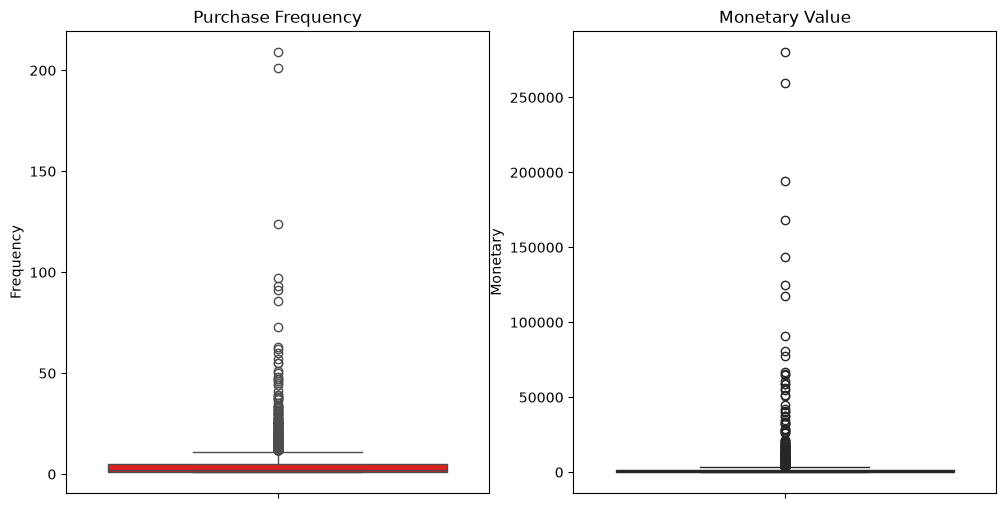

In [28]:
#outliers

plt.figure(figsize=(12,6));
plt.subplot(1,2,1);
sns.boxplot(y=rfm_df['Frequency'],color='red');
plt.title("Purchase Frequency");
plt.subplot(1,2,2);
sns.boxplot(y=rfm_df['Monetary'],color='green');
plt.title("Monetary Value");
plt.show();

In [35]:
#Investigating very high-value wholesalers
#Investigating top 1 % wholesalers
monetary_99 = rfm_df['Monetary'].quantile(0.99);
high_value_wholeSalers = rfm_df[rfm_df['Monetary']>monetary_99].sort_values(by='Monetary',ascending=False);
print("\n--High Value Wholesalers--");
print(high_value_wholeSalers[['CustomerID','Frequency','Monetary']]);




--High Value Wholesalers--
      CustomerID  Frequency   Monetary
1689       14646         73  280206.02
4201       18102         60  259657.30
3728       17450         46  194390.79
3008       16446          2  168472.50
1879       14911        201  143711.17
55         12415         21  124914.53
1333       14156         55  117210.08
3771       17511         31   91062.38
2702       16029         63   80850.84
0          12346          1   77183.60
3176       16684         28   66653.56
1289       14096         17   65164.79
996        13694         50   65039.62
2176       15311         91   60632.75
562        13089         97   58762.08
4093       17949         45   58510.48
2517       15769         26   56252.72
1983       15061         48   54534.14
1434       14298         44   51527.30
1284       14088         13   50491.81
2502       15749          3   44534.30
453        12931         15   42055.96
4010       17841        124   40519.84
2011       15098          3   39916.

In [38]:
#log transformation is best suited for transaction datasets as it includes very high skewness
rfm_df['Log_Monetary']=np.log1p(rfm_df['Monetary']);
rfm_df['Log_Frequency']=np.log1p(rfm_df['Frequency']);

print(rfm_df[['Monetary','Log_Monetary','Frequency','Log_Frequency']]);


      Monetary  Log_Monetary  Frequency  Log_Frequency
0     77183.60     11.253955          1       0.693147
1      4310.00      8.368925          7       2.079442
2      1797.24      7.494564          4       1.609438
3      1757.55      7.472245          1       0.693147
4       334.40      5.815324          1       0.693147
...        ...           ...        ...            ...
4333    180.60      5.201806          1       0.693147
4334     80.82      4.404522          1       0.693147
4335    178.05      5.187665          2       1.098612
4336   2045.53      7.623901         16       2.833213
4337   1837.28      7.516586          3       1.386294

[4338 rows x 4 columns]


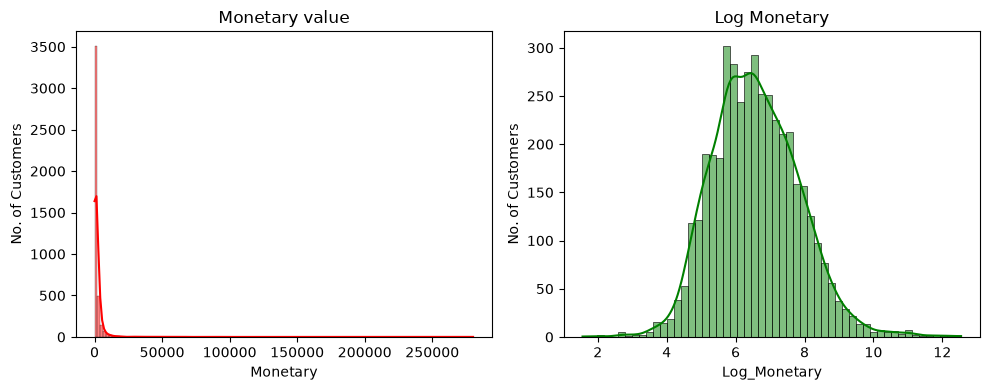

In [52]:
#compare using graphs
#Monetary
plt.figure(figsize=(10,4));
plt.subplot(1,2,1);
sns.histplot(data=rfm_df,x=rfm_df['Monetary'],color='red',kde=True);
plt.ylabel('No. of Customers')
plt.title("Monetary value");
plt.subplot(1,2,2);
sns.histplot(data=rfm_df,x=rfm_df['Log_Monetary'],color='green',kde=True);
plt.title("Log Monetary");
plt.ylabel('No. of Customers');
plt.tight_layout();
plt.show();

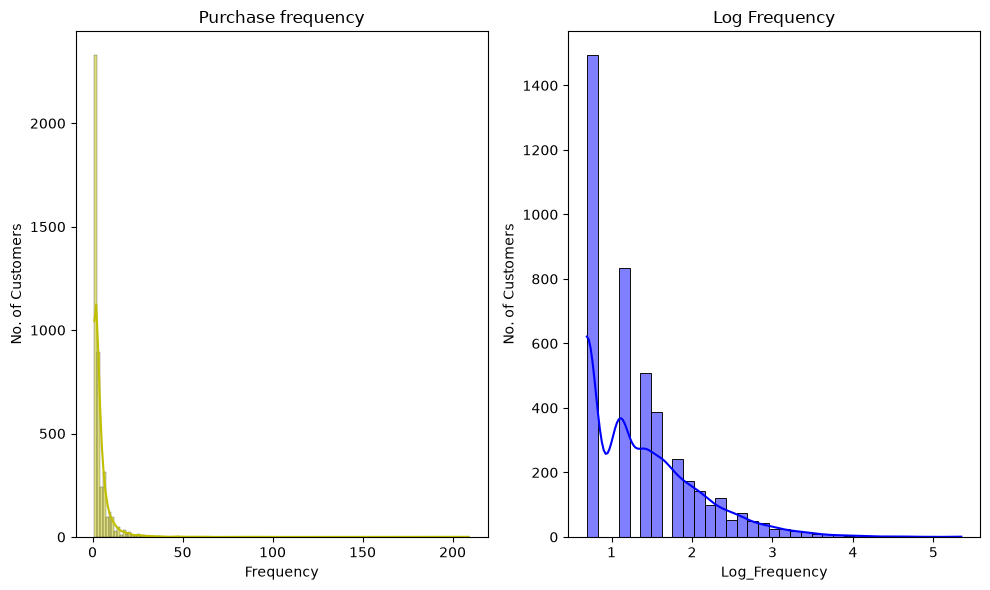

In [51]:
#compare using graphs
#Frequency
plt.figure(figsize=(10,6));
plt.subplot(1,2,1);
sns.histplot(data=rfm_df,x=rfm_df['Frequency'],color='y',kde=True);
plt.ylabel('No. of Customers')
plt.title("Purchase frequency");
plt.subplot(1,2,2);
sns.histplot(data=rfm_df,x=rfm_df['Log_Frequency'],color='b',kde=True);
plt.title("Log Frequency");
plt.ylabel('No. of Customers');
plt.tight_layout()
plt.show();